在决策树回归中，选择如何划分节点的依据是最小化 节点划分后的均方误差（MSE）。假设我们在节点 $T$ 上选择了一个特征 $X_j$ 进行划分，使用阈值 $v$ 来将数据划分为两部分：左子节点和右子节点。
- 左子节点包含所有满足 $X_j \leq v$ 的数据点。
- 右子节点包含所有满足 $X_j > v$ 的数据点。
对于节点 $T$，假设左子节点的均方误差是 $\text{MSE}_{\text{left}}$，右子节点的均方误差是 $\text{MSE}_{\text{right}}$，则总的均方误差为：
$$\text{MSE}_T = \frac{n_{\text{left}}}{n_T} \cdot \text{MSE}_{\text{left}} + \frac{n_{\text{right}}}{n_T} \cdot \text{MSE}_{\text{right}}$$
其中：
$n_T$ 是节点 $T$ 的样本数
$n_{\text{left}}$ 和 $n_{\text{right}}$ 分别是左子节点和右子节点的样本数
3. 计算子节点的均方误差（MSE）
对于每个子节点 $T_{\text{left}}$ 和 $T_{\text{right}}$，它们的均方误差 $\text{MSE}_{\text{left}}$ 和 $\text{MSE}_{\text{right}}$ 分别定义为：
$$\text{MSE}_{\text{left}} = \frac{1}{n_{\text{left}}} \sum_{i \in T_{\text{left}}} (y_i - \hat{y}_{\text{left}})^2$$
$$\text{MSE}_{\text{right}} = \frac{1}{n_{\text{right}}} \sum_{i \in T_{\text{right}}} (y_i - \hat{y}_{\text{right}})^2$$
其中：
$\hat{y}_{\text{left}}$ 是左子节点样本的预测均值，通常取左子节点所有样本 $y_i$ 的均值。
$\hat{y}_{\text{right}}$ 是右子节点样本的预测均值，通常取右子节点所有样本 $y_i$ 的均值。

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(X.head())
print(y.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
dtype: float64


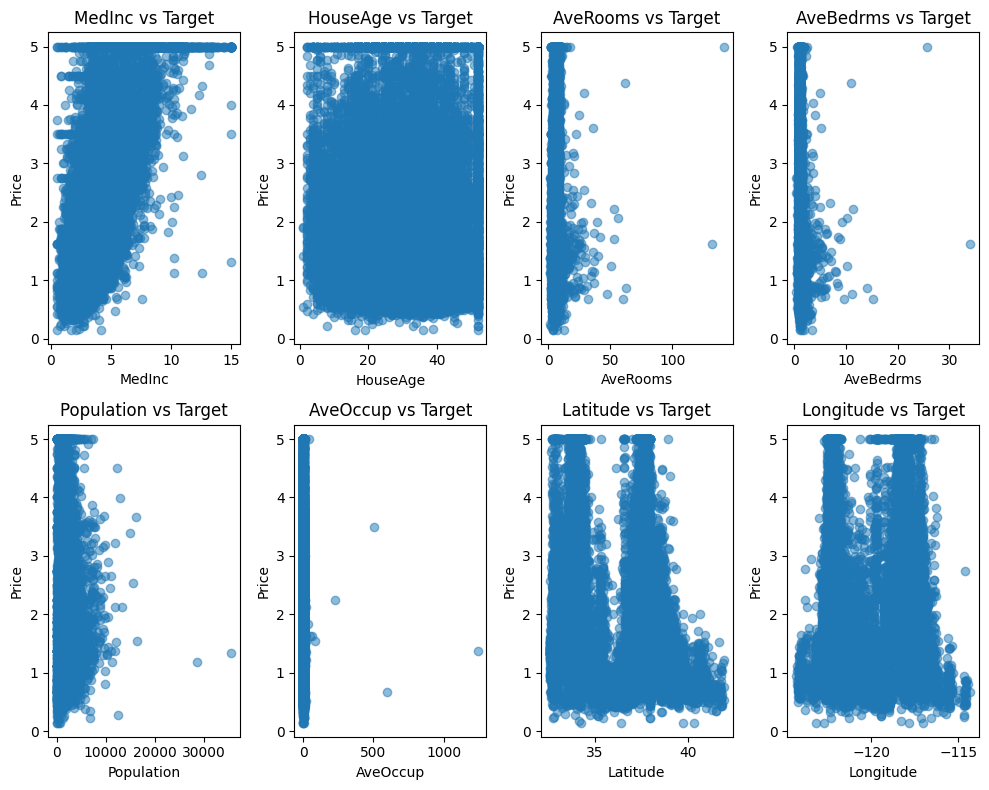

In [5]:
plt.figure(figsize=(10, 8))

for i, column in enumerate(X.columns):
    plt.subplot(2, 4, i+1)
    plt.scatter(X[column], y, alpha=0.5)
    plt.title(f'{column} vs Target')
    plt.xlabel(column)
    plt.ylabel('Price')

plt.tight_layout()
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
pipeline = make_pipeline(StandardScaler(), DecisionTreeRegressor(random_state=42))
## StandardScaler其实不需要,因为决策树不按照距离计算
param_grid = {
    'decisiontreeregressor__max_depth': [5, 10, 15, 20, None],
    'decisiontreeregressor__min_samples_split': [2, 5, 10],
    'decisiontreeregressor__min_samples_leaf': [1, 2, 4],
    'decisiontreeregressor__max_features': ['sqrt', 'log2', None]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'decisiontreeregressor__max_depth': [5, 10, ...], 'decisiontreeregressor__max_features': ['sqrt', 'log2', ...], 'decisiontreeregressor__min_samples_leaf': [1, 2, ...], 'decisiontreeregressor__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbo

In [11]:
print("Best parameters:", grid.best_params_)
print("Best cross-validation MSE:", -grid.best_score_)

Best parameters: {'decisiontreeregressor__max_depth': 10, 'decisiontreeregressor__max_features': None, 'decisiontreeregressor__min_samples_leaf': 4, 'decisiontreeregressor__min_samples_split': 2}
Best cross-validation MSE: 0.3876198504597946


In [13]:
y_pred = grid.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test MSE: {mse:.2f}, Test R^2: {r2:.2f}")

Test MSE: 0.41, Test R^2: 0.69


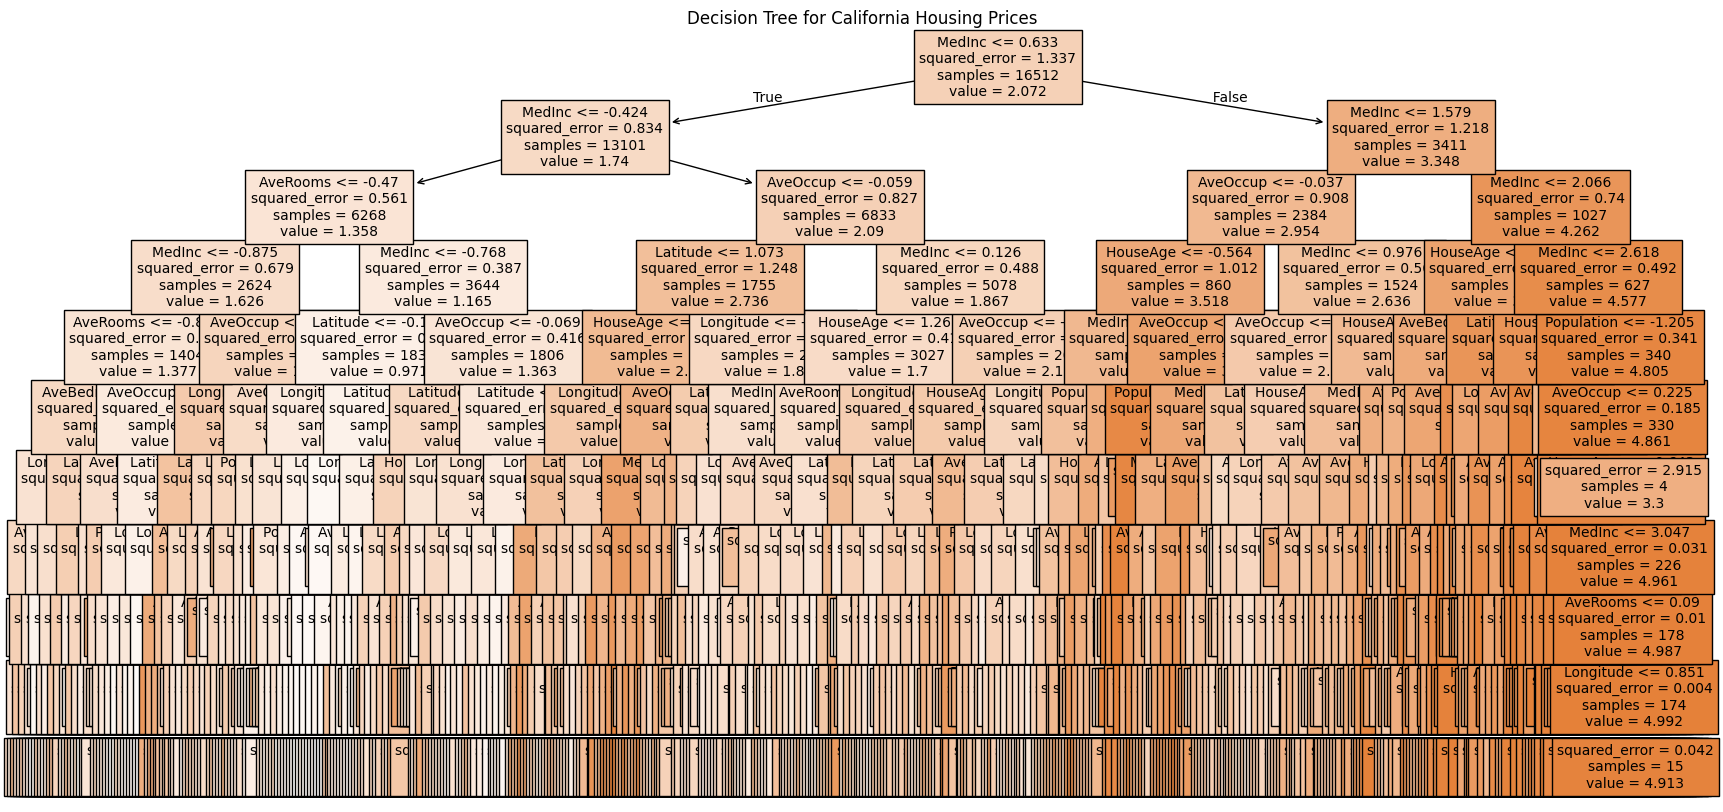

In [17]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
tree_model = grid.best_estimator_.named_steps['decisiontreeregressor']
plot_tree(tree_model, filled=True, feature_names=X.columns, fontsize=10)
plt.title("Decision Tree for California Housing Prices")
plt.show()

In [22]:
for name, importance in zip(X.columns, tree_model.feature_importances_):
    print(f"{name}: {importance:.4f}")

MedInc: 0.6170
HouseAge: 0.0449
AveRooms: 0.0375
AveBedrms: 0.0117
Population: 0.0131
AveOccup: 0.1310
Latitude: 0.0792
Longitude: 0.0655


In [18]:
train_mse = mean_squared_error(y_train, grid.predict(X_train))
train_r2 = r2_score(y_train, grid.predict(X_train))
print(f"Train MSE: {train_mse:.2f}, Train R^2: {train_r2:.2f}")

Train MSE: 0.24, Train R^2: 0.82


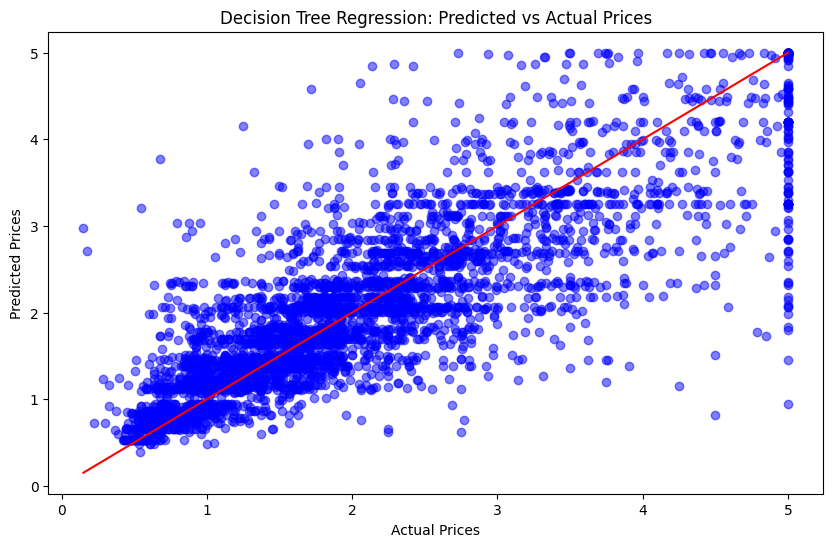

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Prediction')
plt.title("Decision Tree Regression: Predicted vs Actual Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()